### Importación de Librerías y Configuración del Entorno

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)
import joblib

# Permitir importar desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Configuración gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Dispositivo para inferencia: {device}")

⚡ Dispositivo para inferencia: cpu


### Carga de Datos de Prueba y Modelo Entrenado

In [4]:
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

# 1. Cargar datos de prueba procesados y sus etiquetas reales (0: Lícita, 1: Ilícita)
X_test = np.load(PROCESSED_DATA_PATH / "X_test.npy")
y_test = np.load(PROCESSED_DATA_PATH / "y_test.npy")

print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Distribución de etiquetas y_test -> Lícitas (0): {(y_test == 0).sum()} | Ilícitas (1): {(y_test == 1).sum()}")

# 2. Cargar la arquitectura e hiperparámetros del modelo
INPUT_DIM = X_test.shape[1] # 165
BOTTLENECK_DIM = 16

model = Autoencoder(input_dim=INPUT_DIM, bottleneck_dim=BOTTLENECK_DIM)
model.load_state_dict(torch.load(MODELS_DIR / "autoencoder_licit.pth", map_location=device))
model.to(device)
model.eval()

print("✅ Modelo entrenado cargado exitosamente en modo evaluación (eval).")

Dimensiones de X_test: (16670, 165)
Distribución de etiquetas y_test -> Lícitas (0): 15587 | Ilícitas (1): 1083
✅ Modelo entrenado cargado exitosamente en modo evaluación (eval).


### Cálculo del Error de Reconstrucción ($\mathcal{L}_{\text{MSE}}$) Muestra por Muestra
Calculamos la pérdida de reconstrucción por transacción:$$E_i = \frac{1}{d} \sum_{j=1}^{d} (x_{ij} - \hat{x}_{ij})^2$$

In [5]:
# Convertir conjunto de prueba a Tensor de PyTorch
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Realizar inferencia sin calcular gradientes
with torch.no_grad():
    X_test_reconstructed = model(X_test_tensor)

# Convertir a numpy
X_test_reconstructed = X_test_reconstructed.cpu().numpy()

# Error Cuadrático Medio por muestra (promedio a lo largo de las 165 características)
reconstruction_errors = np.mean(np.square(X_test - X_test_reconstructed), axis=1)

print(f"Error de Reconstrucción Promedio Global: {reconstruction_errors.mean():.4f}")
print(f"  └─ Promedio en Lícitas (Clase 0): {reconstruction_errors[y_test == 0].mean():.4f}")
print(f"  └─ Promedio en Ilícitas (Clase 1): {reconstruction_errors[y_test == 1].mean():.4f}")

Error de Reconstrucción Promedio Global: 0.8737
  └─ Promedio en Lícitas (Clase 0): 0.9100
  └─ Promedio en Ilícitas (Clase 1): 0.3518


### Visualización de Distribuciones del Error (Hipótesis de la Variedad)

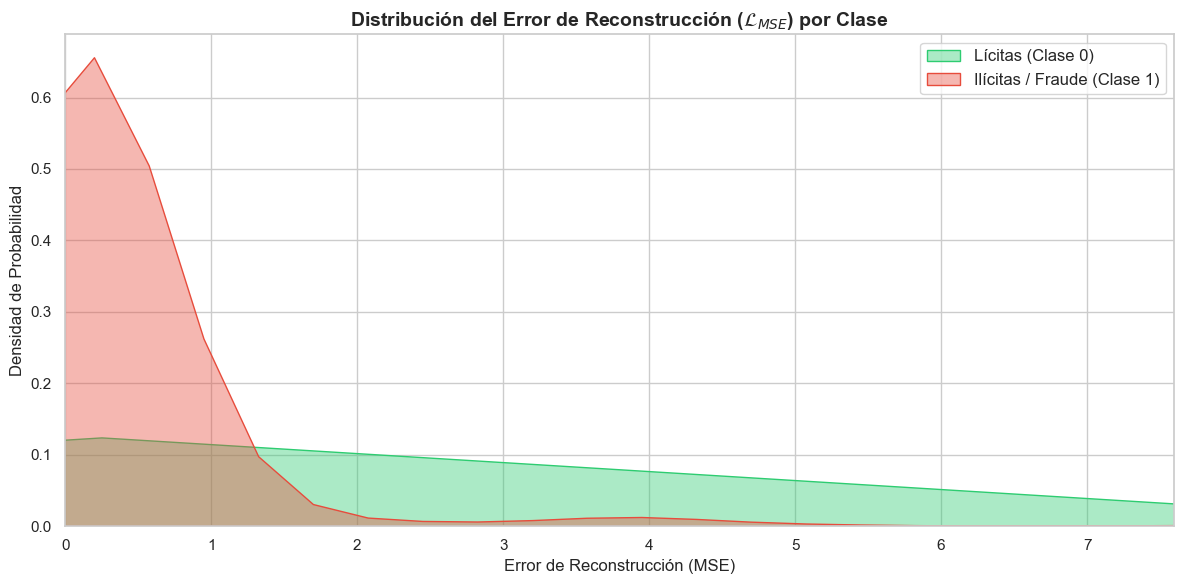

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

# Histogramas/KDE por clase
sns.kdeplot(reconstruction_errors[y_test == 0], label="Lícitas (Clase 0)", color="#2ecc71", fill=True, alpha=0.4, ax=ax)
sns.kdeplot(reconstruction_errors[y_test == 1], label="Ilícitas / Fraude (Clase 1)", color="#e74c3c", fill=True, alpha=0.4, ax=ax)

ax.set_title("Distribución del Error de Reconstrucción ($\mathcal{L}_{MSE}$) por Clase", fontsize=14, fontweight='bold')
ax.set_xlabel("Error de Reconstrucción (MSE)", fontsize=12)
ax.set_ylabel("Densidad de Probabilidad", fontsize=12)
ax.set_xlim([0, np.percentile(reconstruction_errors, 99)])  # Acotar outliers extremos para mejor vista
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Curvas PR-AUC (Precision-Recall) y ROC-AUC
Dado el alto desbalance de clases, la métrica principal de referencia debe ser PR-AUC (Área bajo la curva Precision-Recall) en lugar del Accuracy convencional.

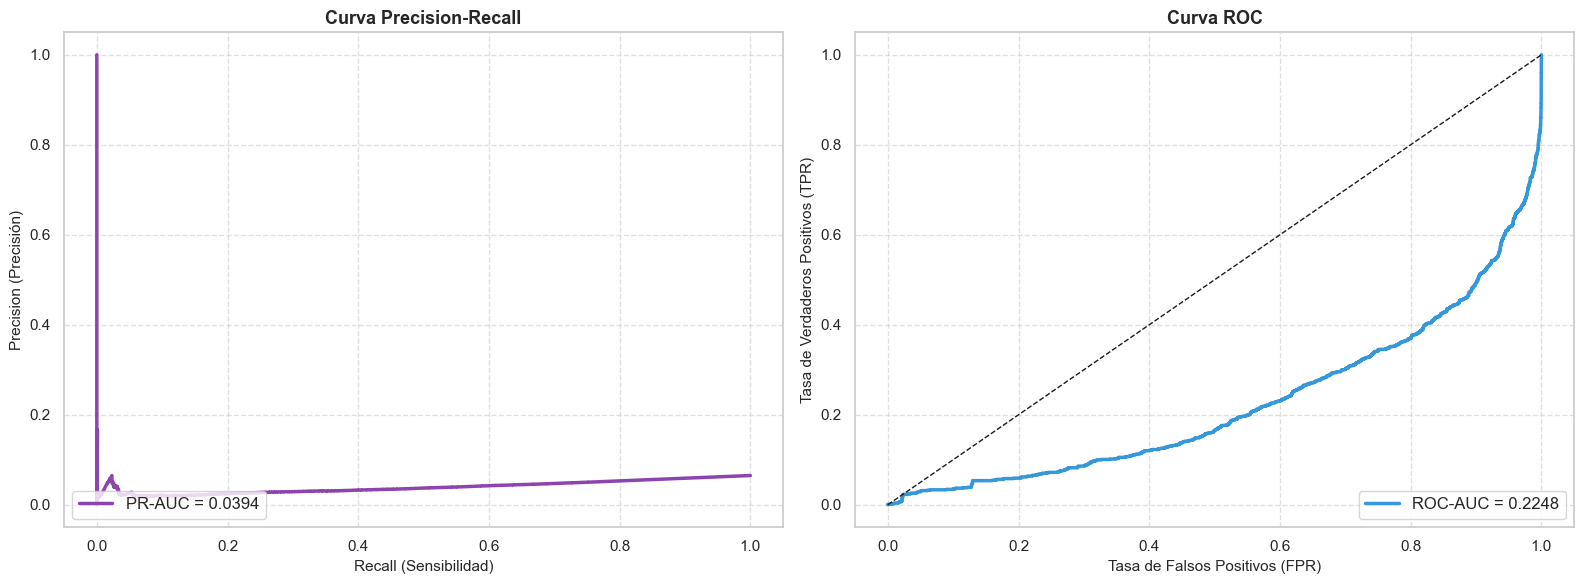

In [7]:
# 1. Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, reconstruction_errors)
pr_auc = auc(recall, precision)

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, reconstruction_errors)
roc_auc = roc_auc_score(y_test, reconstruction_errors)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico PR Curve
axes[0].plot(recall, precision, color='#8e44ad', lw=2.5, label=f'PR-AUC = {pr_auc:.4f}')
axes[0].set_title("Curva Precision-Recall", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Recall (Sensibilidad)", fontsize=11)
axes[0].set_ylabel("Precision (Precisión)", fontsize=11)
axes[0].legend(loc="lower left", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico ROC Curve
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5, label=f'ROC-AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Curva ROC", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Optimización del Umbral de Anomalía ($\tau$) por $F_1$-Score Maximizado
Buscamos el umbral $\tau$ que optimiza el balance entre Precision y Recall ($F_1$-Score):$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [8]:
# Calcular F1-Score para cada umbral disponible
f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)

# Encontrar el índice del F1 máximo
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🎯 Umbral Óptimo Seleccionado (tau): {optimal_threshold:.6f}")
print(f"   ├─ Precision en el umbral: {precision[best_idx]:.4f}")
print(f"   ├─ Recall en el umbral:    {recall[best_idx]:.4f}")
print(f"   └─ F1-Score Máximo:        {best_f1:.4f}")

🎯 Umbral Óptimo Seleccionado (tau): 0.025767
   ├─ Precision en el umbral: 0.0650
   ├─ Recall en el umbral:    1.0000
   └─ F1-Score Máximo:        0.1220


### Evaluación Final con Matriz de Confusión y Reporte

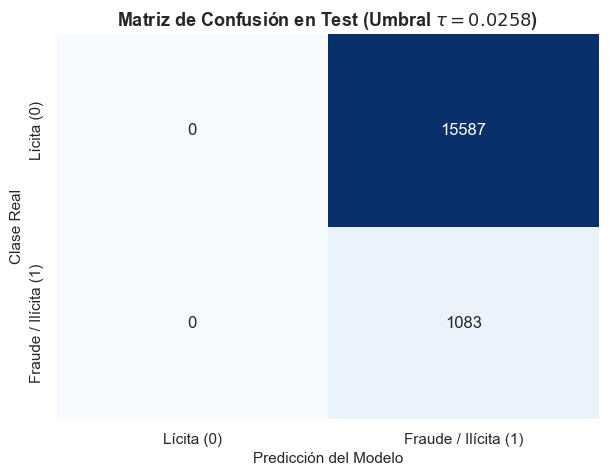


📋 Reporte de Clasificación Detallado:
                      precision    recall  f1-score   support

          Lícita (0)     0.0000    0.0000    0.0000     15587
Ilícita / Fraude (1)     0.0650    1.0000    0.1220      1083

            accuracy                         0.0650     16670
           macro avg     0.0325    0.5000    0.0610     16670
        weighted avg     0.0042    0.0650    0.0079     16670



c:\Users\USUARIO\.vscode\Proyectos\elliptic-fraud-detection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USUARIO\.vscode\Proyectos\elliptic-fraud-detection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USUARIO\.vscode\Proyectos\elliptic-fraud-detection\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [9]:
# Clasificar predicciones según el umbral óptimo tau
y_pred = (reconstruction_errors >= optimal_threshold).astype(int)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Lícita (0)", "Fraude / Ilícita (1)"],
            yticklabels=["Lícita (0)", "Fraude / Ilícita (1)"])

plt.title(f"Matriz de Confusión en Test (Umbral $\\tau = {optimal_threshold:.4f}$)", fontsize=13, fontweight='bold')
plt.xlabel("Predicción del Modelo", fontsize=11)
plt.ylabel("Clase Real", fontsize=11)
plt.show()

# Reporte detallado de clasificación
print("\n📋 Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred, target_names=["Lícita (0)", "Ilícita / Fraude (1)"], digits=4))

### Guardar Artefactos de Evaluación

In [10]:
# Guardar el umbral óptimo tau para inferencia en producción
threshold_dict = {
    "optimal_threshold": float(optimal_threshold),
    "best_f1_score": float(best_f1),
    "pr_auc": float(pr_auc),
    "roc_auc": float(roc_auc)
}

joblib.dump(threshold_dict, PROCESSED_DATA_PATH / "threshold_config.joblib")

print("💾 Configuración del umbral guardada exitosamente en data/processed/threshold_config.joblib")

💾 Configuración del umbral guardada exitosamente en data/processed/threshold_config.joblib


In [11]:
# Cargar train_licit para comparar la distribución de error original
X_train_licit = np.load(PROCESSED_DATA_PATH / "X_train_licit.npy")

with torch.no_grad():
    X_tr_tensor = torch.tensor(X_train_licit, dtype=torch.float32).to(device)
    X_tr_rec = model(X_tr_tensor).cpu().numpy()

train_errors = np.mean(np.square(X_train_licit - X_tr_rec), axis=1)

test_errors_licit = reconstruction_errors[y_test == 0]
test_errors_fraud = reconstruction_errors[y_test == 1]

print("=" * 70)
print("📊 DIAGNÓSTICO 1: DISTRIBUCIÓN DE ERRORES (MSE)")
print("=" * 70)
print(f"TRAIN (Lícito)  | Min: {train_errors.min():.6f} | Mediana: {np.median(train_errors):.6f} | P95: {np.percentile(train_errors, 95):.6f} | Max: {train_errors.max():.6f}")
print(f"TEST  (Lícito)  | Min: {test_errors_licit.min():.6f} | Mediana: {np.median(test_errors_licit):.6f} | P95: {np.percentile(test_errors_licit, 95):.6f} | Max: {test_errors_licit.max():.6f}")
print(f"TEST  (Ilícito) | Min: {test_errors_fraud.min():.6f} | Mediana: {np.median(test_errors_fraud):.6f} | P95: {np.percentile(test_errors_fraud, 95):.6f} | Max: {test_errors_fraud.max():.6f}")
print("=" * 70)

📊 DIAGNÓSTICO 1: DISTRIBUCIÓN DE ERRORES (MSE)
TRAIN (Lícito)  | Min: 0.017290 | Mediana: 0.185684 | P95: 0.597237 | Max: 164.166222
TEST  (Lícito)  | Min: 0.035876 | Mediana: 0.269001 | P95: 1.921586 | Max: 1889.401694
TEST  (Ilícito) | Min: 0.025767 | Mediana: 0.114677 | P95: 0.956482 | Max: 71.235203


In [12]:
print("=" * 70)
print("⚙️ DIAGNÓSTICO 2: INSPECCIÓN DE VECTORES Y UMBRAL")
print("=" * 70)
print(f"Tamaño Precision:  {len(precision)}")
print(f"Tamaño Recall:     {len(recall)}")
print(f"Tamaño Thresholds: {len(thresholds)}")
print(f"Índice Seleccionado (best_idx): {best_idx}")
print(f"Umbral Calculado (tau): {optimal_threshold:.6f}")
print(f"Error Mínimo en Test:   {reconstruction_errors.min():.6f}")
print(f"Error Máximo en Test:   {reconstruction_errors.max():.6f}")
print(f"¿Tau < Mínimo error de Test?: {optimal_threshold < reconstruction_errors.min()}")
print("=" * 70)

⚙️ DIAGNÓSTICO 2: INSPECCIÓN DE VECTORES Y UMBRAL
Tamaño Precision:  16671
Tamaño Recall:     16671
Tamaño Thresholds: 16670
Índice Seleccionado (best_idx): 0
Umbral Calculado (tau): 0.025767
Error Mínimo en Test:   0.025767
Error Máximo en Test:   1889.401694
¿Tau < Mínimo error de Test?: False
